In [1]:
!git clone https://github.com/hananbahtiti/School.git

Cloning into 'School'...
remote: Enumerating objects: 19, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (17/17), done.
remote: Total 19 (delta 6), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (19/19), 293.23 KiB | 1.17 MiB/s, done.
Resolving deltas: 100% (6/6), done.


In [2]:
import pandas as pd
from sklearn import preprocessing
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Data Dictionary / Column Descriptions

| Column Name                          | Description                                                                                          |
|------------------------------------|----------------------------------------------------------------------------------------------------|
| **DBN**                            | District Borough Number — unique identifier assigned to each school within the NYC Department of Education system. |
| **School Name**                    | The official full name of the school.                                                              |
| **School Type**                    | Classification of the school, such as Elementary, Middle, or High School.                           |
| **Parent Response Rate** (%)      | Percentage of parents who responded to the school survey, indicating parent engagement.            |
| **Teacher Response Rate** (%)     | Percentage of teachers who participated in the survey, reflecting staff involvement.               |
| **Student Response Rate** (%)     | Percentage of students who completed the survey, measuring student participation.                   |
| **Total Safety and Respect Score**| Aggregate score assessing perceptions of safety and respect within the school environment.         |
| **Total Communication Score**     | Score evaluating the effectiveness of communication between the school, families, and staff.       |
| **Total Engagement Score**        | Score measuring the level of engagement among students, families, and staff.                        |
| **Total Academic Expectations Score** | Score representing the academic expectations and rigor promoted by the school.                  |


In [69]:
# Load the dataset from the specified CSV file path into a DataFrame
file = '/content/School/General_Education_School.csv'
df = pd.read_csv(file)

# Display a concise summary of the DataFrame including column names, data types, and non-null counts
print(f"{df.info()}")

# Display the first five rows of the dataset for a quick preview of the data
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1671 entries, 0 to 1670
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   DBN                                1671 non-null   object
 1   School Name                        1671 non-null   object
 2   School Type                        1670 non-null   object
 3   Parent Response Rate               1671 non-null   object
 4   Teacher Response Rate              1671 non-null   object
 5   Student Response Rate              996 non-null    object
 6   Total Safety and Respect Score     1671 non-null   object
 7   Total Communication Score          1671 non-null   object
 8   Total Engagement Score             1671 non-null   object
 9   Total Academic Expectations Score  1671 non-null   object
dtypes: object(10)
memory usage: 130.7+ KB
None


,DBN,School Name,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
0,dbn,locationname,NaN,rr_p,rr_t,rr_s,saf_tot_12,com_tot_12,eng_tot_12,aca_tot_12
1,01M015,P.S. 015 Roberto Clemente,Elementary School,61%,92%,NaN,8.4,8.2,8.3,8.2
2,01M019,P.S. 019 Asher Levy,Elementary School,92%,94%,NaN,8.4,8,8,8.2
3,01M020,P.S. 020 Anna Silver,Elementary School,88%,73%,NaN,8.5,7.8,8.2,8.2
4,01M034,P.S. 034 Franklin D. Roosevelt,Elementary/Middle School,39%,58%,96%,7.3,6.9,7.3,7.7


#**1. Data Cleaning**

In [70]:
# Create a copy of the original DataFrame to avoid modifying it directly
df = df.copy()

# Remove the first row based on its integer position using .iloc
# This is useful when the first row contains metadata or is not part of the actual data
df = df.iloc[1:].copy()

# Display the structure of the DataFrame after removing the first row
df.info()

# Display the first five rows of the updated DataFrame to verify the changes
df.head()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670 entries, 1 to 1670
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype 
---  ------                             --------------  ----- 
 0   DBN                                1670 non-null   object
 1   School Name                        1670 non-null   object
 2   School Type                        1670 non-null   object
 3   Parent Response Rate               1670 non-null   object
 4   Teacher Response Rate              1670 non-null   object
 5   Student Response Rate              995 non-null    object
 6   Total Safety and Respect Score     1670 non-null   object
 7   Total Communication Score          1670 non-null   object
 8   Total Engagement Score             1670 non-null   object
 9   Total Academic Expectations Score  1670 non-null   object
dtypes: object(10)
memory usage: 130.6+ KB


,DBN,School Name,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
1,01M015,P.S. 015 Roberto Clemente,Elementary School,61%,92%,NaN,8.4,8.2,8.3,8.2
2,01M019,P.S. 019 Asher Levy,Elementary School,92%,94%,NaN,8.4,8,8,8.2
3,01M020,P.S. 020 Anna Silver,Elementary School,88%,73%,NaN,8.5,7.8,8.2,8.2
4,01M034,P.S. 034 Franklin D. Roosevelt,Elementary/Middle School,39%,58%,96%,7.3,6.9,7.3,7.7
5,01M063,P.S. 063 William Mckinley,Elementary School,58%,100%,NaN,8.5,7.4,7.6,7.8


In [71]:
# Convert selected survey score columns to float type for accurate numerical analysis
df[['Total Academic Expectations Score',
    'Total Engagement Score',
    'Total Communication Score',
    'Total Safety and Respect Score']] = df[[
        'Total Academic Expectations Score',
        'Total Engagement Score',
        'Total Communication Score',
        'Total Safety and Respect Score'
    ]].astype(float)

# Remove percentage signs and convert response rate columns to integers
# 'errors="coerce"' will convert any invalid entries to NaN
df[['Student Response Rate',
    'Teacher Response Rate',
    'Parent Response Rate']] = df[[
        'Student Response Rate',
        'Teacher Response Rate',
        'Parent Response Rate'
    ]].replace(r'%', '', regex=True).astype('Int64')  # Use nullable integer type


# Display a concise summary of the DataFrame including updated data types and null counts
print(f"{df.info()}")

# Display the first five rows to confirm the changes and inspect data quality
print(df.head())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1670 entries, 1 to 1670
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DBN                                1670 non-null   object 
 1   School Name                        1670 non-null   object 
 2   School Type                        1670 non-null   object 
 3   Parent Response Rate               1670 non-null   Int64  
 4   Teacher Response Rate              1670 non-null   Int64  
 5   Student Response Rate              995 non-null    Int64  
 6   Total Safety and Respect Score     1670 non-null   float64
 7   Total Communication Score          1670 non-null   float64
 8   Total Engagement Score             1670 non-null   float64
 9   Total Academic Expectations Score  1670 non-null   float64
dtypes: Int64(3), float64(4), object(3)
memory usage: 135.5+ KB
None
      DBN                     School Name               

In [72]:
# Remove duplicate rows from the DataFrame to ensure data integrity
df = df.drop_duplicates()

# Display concise summary of the DataFrame including column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1667 entries, 1 to 1667
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DBN                                1667 non-null   object 
 1   School Name                        1667 non-null   object 
 2   School Type                        1667 non-null   object 
 3   Parent Response Rate               1667 non-null   Int64  
 4   Teacher Response Rate              1667 non-null   Int64  
 5   Student Response Rate              994 non-null    Int64  
 6   Total Safety and Respect Score     1667 non-null   float64
 7   Total Communication Score          1667 non-null   float64
 8   Total Engagement Score             1667 non-null   float64
 9   Total Academic Expectations Score  1667 non-null   float64
dtypes: Int64(3), float64(4), object(3)
memory usage: 148.1+ KB


In [73]:
# Calculate and display the percentage of missing (null) values for each column in the DataFrame
# This helps identify data quality issues and assess the need for cleaning or imputation
print(f"Counts of null values (as percentage of total rows): \n{df.isnull().sum() / len(df) * 100}")


Counts of null values (as percentage of total rows): 
DBN                                   0.000000
School Name                           0.000000
School Type                           0.000000
Parent Response Rate                  0.000000
Teacher Response Rate                 0.000000
Student Response Rate                40.371926
Total Safety and Respect Score        0.000000
Total Communication Score             0.000000
Total Engagement Score                0.000000
Total Academic Expectations Score     0.000000
dtype: float64


In [74]:
# Count of nulls in 'score' column per school_type
null_counts = df[df['Student Response Rate'].isnull()].groupby('School Type').size()

print(null_counts)

School Type
Early Childhood School     81
Elementary School         589
Middle School               3
dtype: int64


In [75]:
# Replace missing values in the 'Student Response Rate' column with 0
df['Student Response Rate'].fillna(0, inplace=True)

# Display a concise summary of the DataFrame, including column types and non-null counts
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1667 entries, 1 to 1667
Data columns (total 10 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   DBN                                1667 non-null   object 
 1   School Name                        1667 non-null   object 
 2   School Type                        1667 non-null   object 
 3   Parent Response Rate               1667 non-null   Int64  
 4   Teacher Response Rate              1667 non-null   Int64  
 5   Student Response Rate              1667 non-null   Int64  
 6   Total Safety and Respect Score     1667 non-null   float64
 7   Total Communication Score          1667 non-null   float64
 8   Total Engagement Score             1667 non-null   float64
 9   Total Academic Expectations Score  1667 non-null   float64
dtypes: Int64(3), float64(4), object(3)
memory usage: 148.1+ KB


<ipython-input-75-e27a217b332d>:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Student Response Rate'].fillna(0, inplace=True)
<ipython-input-75-e27a217b332d>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Student Response Rate'].fillna(0, inplace=True)


#**2. Exploratory Data Analysis**

In [76]:
# Display the number of unique values in each column of the DataFrame
# Useful for understanding the variability and cardinality of features
print(f"{df.nunique()}")


DBN                                  1667
School Name                          1665
School Type                             9
Parent Response Rate                  100
Teacher Response Rate                  83
Student Response Rate                  74
Total Safety and Respect Score         44
Total Communication Score              42
Total Engagement Score                 40
Total Academic Expectations Score      39
dtype: int64


In [77]:
# Iterate through all columns in the DataFrame
# For each column, print its name and display the frequency count of each unique value
# This is useful for understanding the distribution of categorical and discrete data
for col in df.columns:
    print(f'================= {col} =================')
    print(f'{df[col].value_counts()}')


================= DBN =================
DBN
84X730    1
01M015    1
01M019    1
84X482    1
84X461    1
         ..
01M134    1
01M110    1
01M064    1
01M063    1
01M034    1
Name: count, Length: 1667, dtype: int64
================= School Name =================
School Name
P.S. 212                                              2
P.S. 253                                              2
P.S. 012 James B. Colgate                             1
P.S. 007 Louis F. Simeone                             1
I.S. 5 - The Walter Crowley Intermediate School       1
                                                     ..
High School Of American Studies At Lehman College     1
Grace Dodge Yabc                                      1
Grace Dodge Career And Technical Education High Sc    1
Discovery High School                                 1
P.S. 087 Bronx                                        1
Name: count, Length: 1665, dtype: int64
================= School Type =================
School Type
Elementa

In [78]:
# Generate descriptive statistics for all numerical columns in the DataFrame
# Includes metrics such as count, mean, standard deviation, min, max, and quartiles
df.describe()


,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
count,1667.0,1667.0,1667.0,1667.000000,1667.000000,1667.000000,1667.000000
mean,56.335933,83.403119,50.405519,7.850330,7.299820,7.582244,7.879544
std,25.008905,17.426696,43.317526,0.745997,0.697943,0.662616,0.624073
min,1.0,0.0,0.0,4.700000,4.700000,4.800000,5.300000
25%,37.0,75.0,0.0,7.300000,6.800000,7.100000,7.500000
50%,57.0,88.0,71.0,7.900000,7.300000,7.600000,7.900000
75%,76.0,97.0,92.0,8.400000,7.800000,8.000000,8.300000
max,100.0,100.0,100.0,9.600000,9.200000,9.300000,9.500000


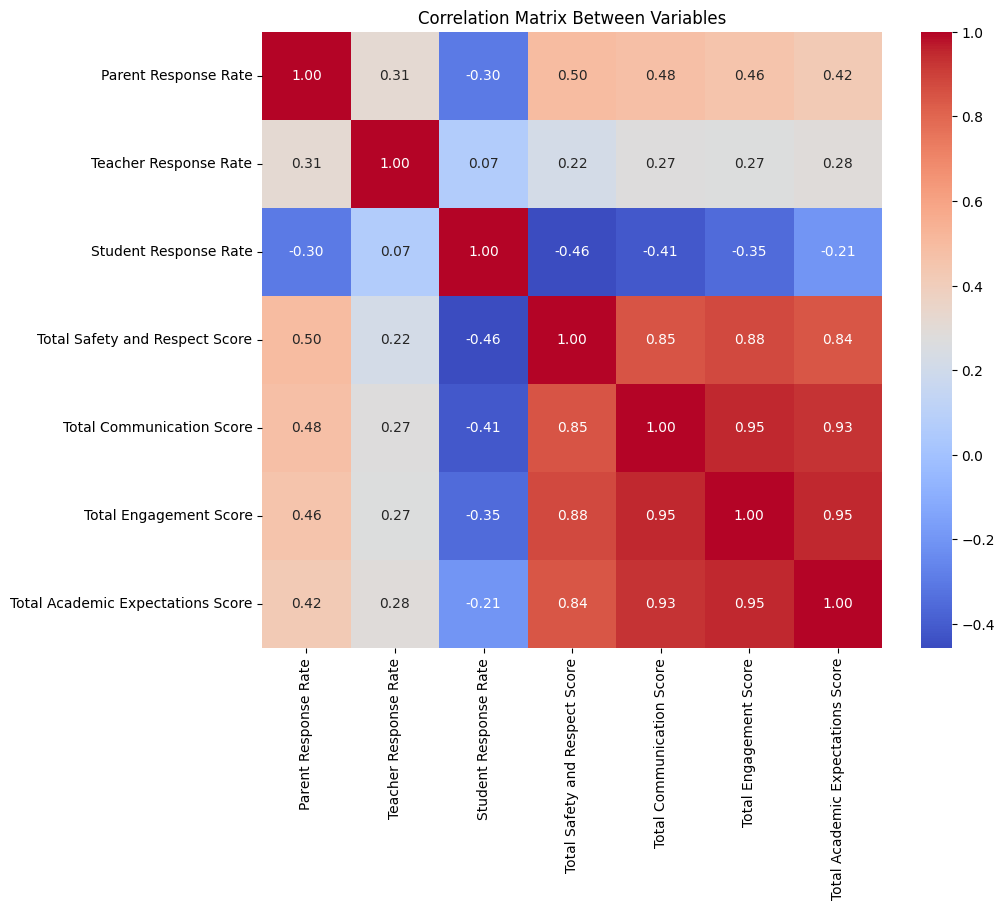

In [79]:
# Set the size of the figure for better readability
plt.figure(figsize=(10, 8))

# Select only numeric columns before calculating the correlation matrix
# This prevents errors if non-numeric columns (like 'DBN') are present
numeric_df = df.select_dtypes(include=['number'])

# Generate a heatmap to visualize the correlation matrix between variables
# Use the numeric_df to calculate correlations
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt=".2f")

# Set the title of the heatmap
plt.title('Correlation Matrix Between Variables')

# Display the heatmap
plt.show()

#**3. Deep Dive**

(array([0, 1, 2, 3, 4, 5, 6, 7, 8]),
 [Text(0, 0, 'Elementary School'),
  Text(1, 0, 'High School'),
  Text(2, 0, 'Middle School'),
  Text(3, 0, 'Elementary/Middle School'),
  Text(4, 0, 'Middle/High School'),
  Text(5, 0, 'Early Childhood School'),
  Text(6, 0, 'Transfer High School'),
  Text(7, 0, 'YABC'),
  Text(8, 0, 'Elementary/Middle/High School')])

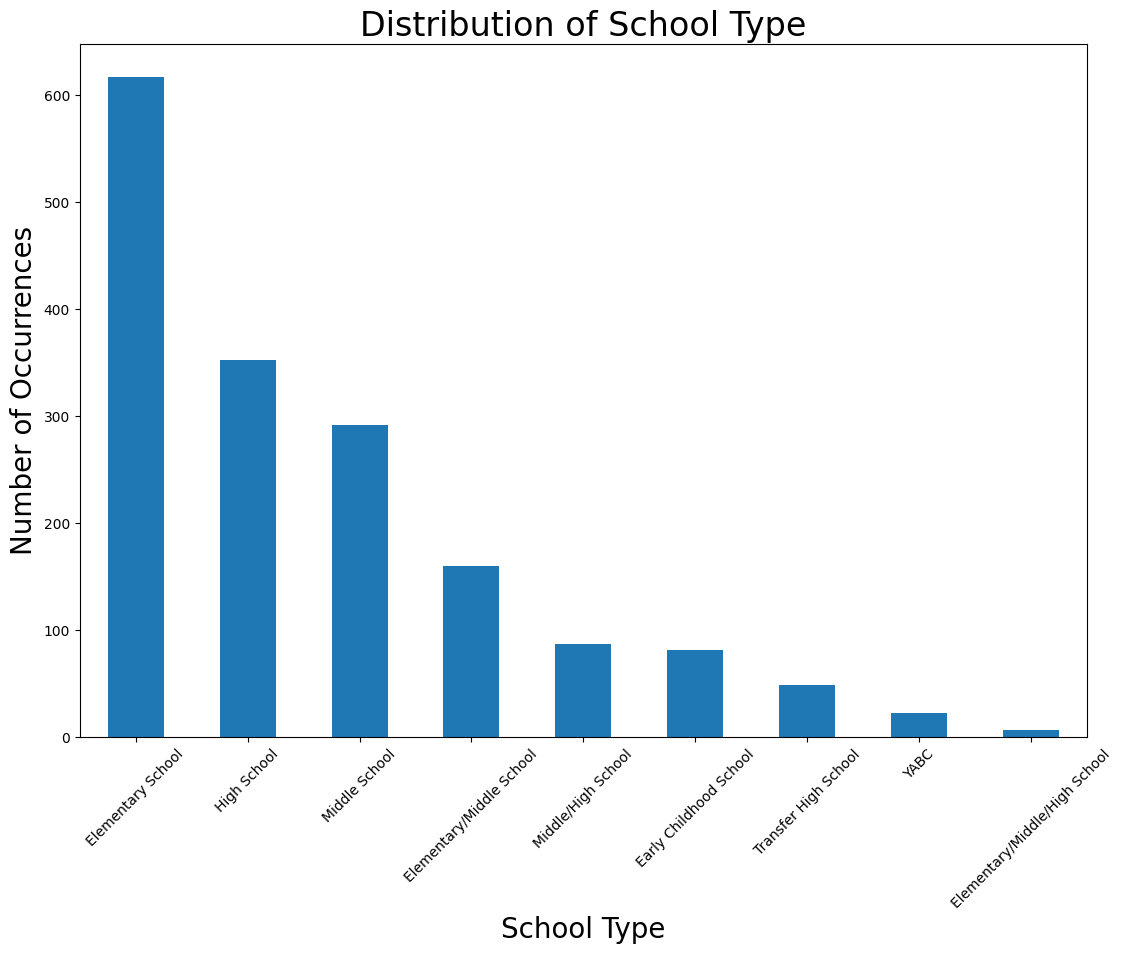

In [20]:
# Group the data by 'Parent Response Rate' and 'Total Communication Score' and count the number of occurrences
# This helps to analyze how frequently each combination appears
Parent = df.groupby(['School Type']).size()

# Sort the grouped data in descending order for better visualization
Parent_sorted = Parent.sort_values(ascending=False)

# Plotting the grouped and sorted data as a bar chart
plt.figure(figsize=(13, 9))
Parent_sorted.plot(kind='bar', linewidth=3)

# Set title and axis labels with proper formatting
plt.title('Distribution of School Type', fontsize=24)
plt.xlabel('School Type', fontsize=20)
plt.ylabel('Number of Occurrences', fontsize=20)
plt.xticks(rotation=45)

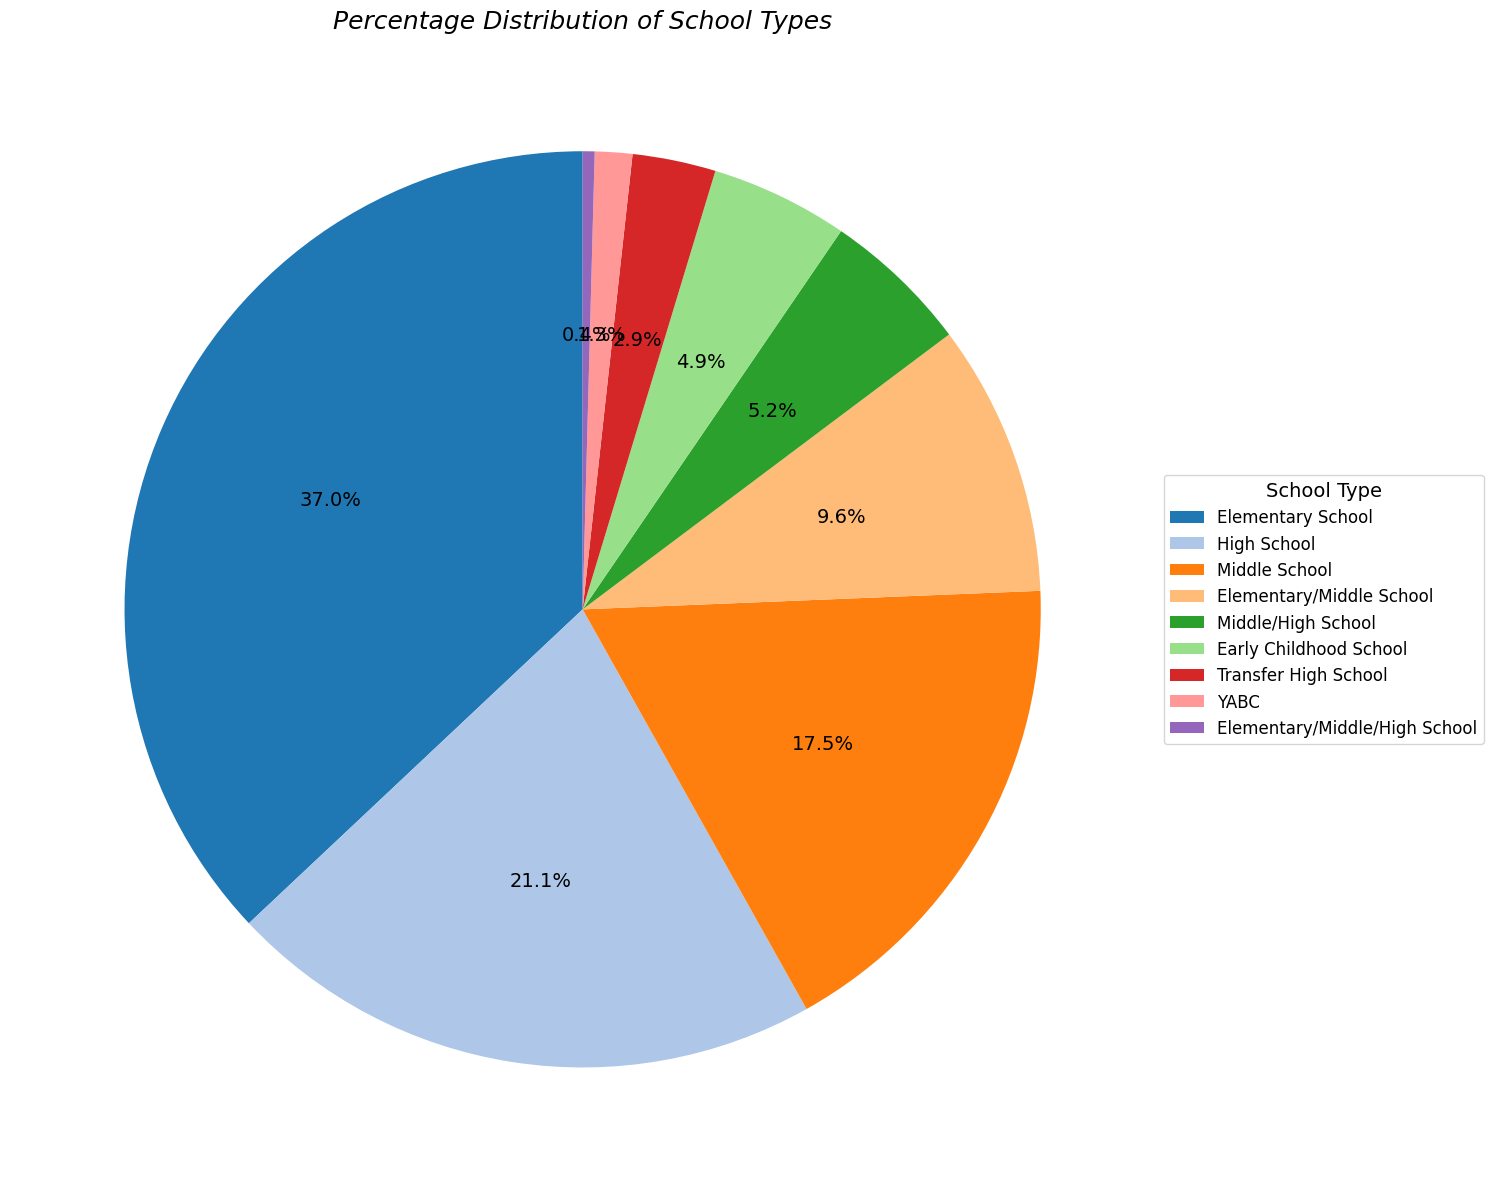

In [21]:
# Calculate the percentage distribution of each category in the 'School Type' column
counts = df['School Type'].value_counts(normalize=True) * 100

# Set up the figure size
fig, ax = plt.subplots(figsize=(15, 15))

# Define custom colors using a colormap to ensure unique colors for each category
colors = plt.cm.tab20.colors[:len(counts)]

# Create the pie chart with percentage labels and custom font size
wedges, texts, autotexts = ax.pie(
    counts.values,
    labels=None,                      # We'll use a legend instead of direct labels
    autopct='%1.1f%%',                # Show percentage with one decimal
    startangle=90,                    # Start the pie from 90 degrees for balance
    colors=colors,
    textprops={'fontsize': 14}        # Font size for the percentage texts
)

# Set chart title with italic font style and larger font size
ax.set_title('Percentage Distribution of School Types', fontstyle='italic', fontsize=18)

# Add a legend to the side showing each school type and its corresponding color
ax.legend(
    wedges,
    counts.index,
    title="School Type",
    loc="center left",
    bbox_to_anchor=(1, 0.5),          # Position the legend outside the chart
    fontsize=12,
    title_fontsize=14
)

# Adjust layout to prevent clipping of the legend
plt.tight_layout()
plt.show()

In [22]:
# Group by 'School Type' and calculate the mean for the selected columns
school_scores = df.groupby(['School Type'])[[
    'Parent Response Rate',
    'Teacher Response Rate',
    'Student Response Rate',
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]].mean().reset_index()

# Convert score columns to percentages (assuming scores are out of 10)
score_columns = [
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]

#school_scores[score_columns] = school_scores[score_columns] * 10

# Display the final DataFrame
school_scores

,School Type,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score
0,Early Childhood School,76.481481,88.444444,0.0,8.637037,8.027160,8.162963,8.386420
1,Elementary School,68.526742,82.418152,4.294976,8.273906,7.645867,7.872609,8.051053
2,Elementary/Middle School,60.9375,82.51875,93.7625,7.661250,7.245625,7.536250,7.961250
3,Elementary/Middle/High School,54.714286,76.285714,91.571429,7.471429,6.857143,7.128571,7.514286
4,High School,35.09375,84.252841,77.494318,7.394886,6.848864,7.157102,7.530966
5,Middle School,58.681507,83.832192,90.287671,7.453082,7.065753,7.416781,7.804795
6,Middle/High School,40.218391,80.045977,83.965517,7.398851,6.847126,7.124138,7.514943
7,Transfer High School,35.653061,89.959184,68.102041,8.091837,7.238776,7.775510,8.044898
8,YABC,25.863636,80.545455,65.863636,8.377273,7.700000,8.159091,8.368182


<ipython-input-111-77e3b5ccd2bd>:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = df.groupby('School Type').apply(


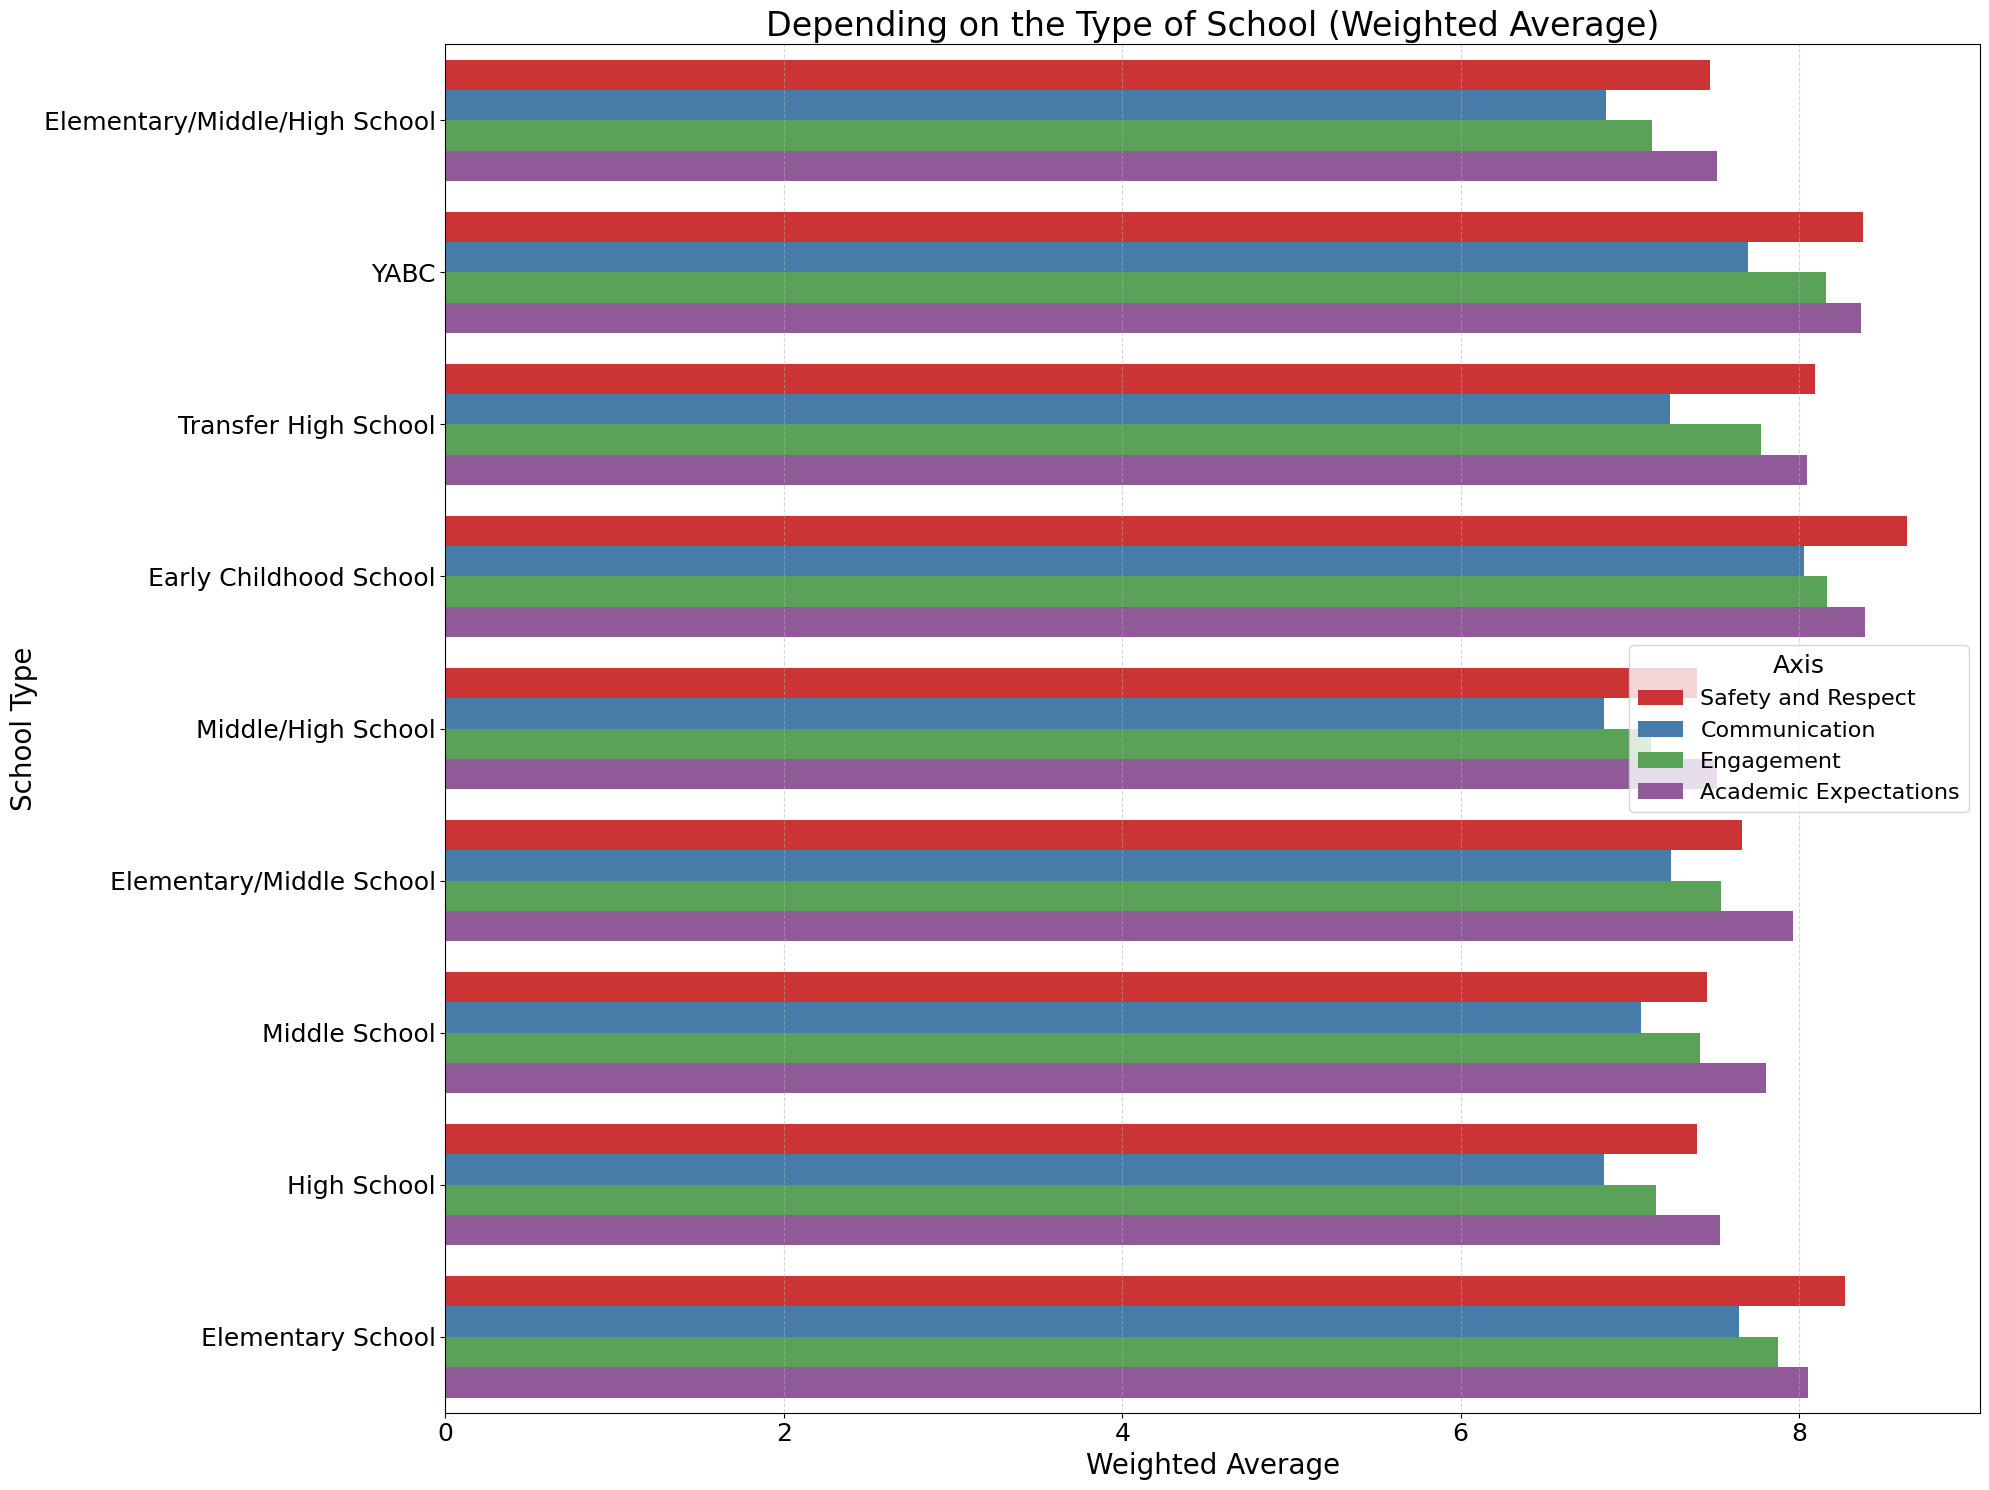

In [111]:

# Define the columns representing the total performance scores
score_cols = [
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]

# Count the number of entries for each School Type
school_counts = df['School Type'].value_counts()

# Assign weights to each row based on the inverse of school type frequency
df['weight'] = df['School Type'].map(1 / school_counts)

# Compute the weighted average for each score category per school type
weighted_means = df.groupby('School Type').apply(
    lambda g: pd.Series({
        col: (
            pd.to_numeric(g[col], errors='coerce') *
            pd.to_numeric(g['weight'], errors='coerce')
        ).sum() / pd.to_numeric(g['weight'], errors='coerce').sum()
        for col in score_cols
    })
).reset_index()

# Sort school types by number of records (ascending) for better visual grouping
sorted_types = school_counts.sort_values(ascending=True).index.to_list()
weighted_means = weighted_means.set_index('School Type').loc[sorted_types].reset_index()

# Map original score column names to shorter, user-friendly labels
score_cols_readable = {
    'Total Safety and Respect Score': 'Safety and Respect',
    'Total Communication Score': 'Communication',
    'Total Engagement Score': 'Engagement',
    'Total Academic Expectations Score': 'Academic Expectations'
}

# Reshape the data from wide to long format for seaborn barplot
melted = weighted_means.melt(
    id_vars='School Type',
    value_vars=score_cols,
    var_name='Score Type',
    value_name='Weighted Score'
)

# Apply human-readable labels to the score type
melted['Score Type'] = melted['Score Type'].map(score_cols_readable)

# Set figure size for clarity and presentation quality
plt.figure(figsize=(20, 15))

# Create a horizontal barplot to compare weighted scores by school type
sns.barplot(
    data=melted,
    x='Weighted Score',
    y='School Type',
    hue='Score Type',
    palette='Set1'
)

# Add title and axis labels with increased font sizes
plt.title('Depending on the Type of School (Weighted Average)', fontsize=24)
plt.xlabel('Weighted Average', fontsize=20)
plt.ylabel('School Type', fontsize=20)

# Customize legend and axis tick labels
plt.legend(title='Axis', title_fontsize=18, fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Optimize layout and add grid lines for better readability
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Display the plot
plt.show()

In [106]:

# Step 3: Pivot the DataFrame
df_Score = melted.pivot(index="School Type", columns="Score Type", values="Weighted Score")

# Step 4: Rename columns to your desired names
df_Score.columns = [
    'Safety and Respect',
    'Communication',
    'Engagement',
    'Academic Expectations'
]

# Optional: Reorder columns if needed
df_Score = df_Score[[
    'Safety and Respect',
    'Communication',
    'Engagement',
    'Academic Expectations'
]]

# Step 5: Display the final DataFrame
df_Score

,Safety and Respect,Communication,Engagement,Academic Expectations
School Type,,,,
Early Childhood School,8.386420,8.027160,8.162963,8.637037
Elementary School,8.051053,7.645867,7.872609,8.273906
Elementary/Middle School,7.961250,7.245625,7.536250,7.661250
Elementary/Middle/High School,7.514286,6.857143,7.128571,7.471429
High School,7.530966,6.848864,7.157102,7.394886
Middle School,7.804795,7.065753,7.416781,7.453082
Middle/High School,7.514943,6.847126,7.124138,7.398851
Transfer High School,8.044898,7.238776,7.775510,8.091837
YABC,8.368182,7.700000,8.159091,8.377273


<ipython-input-109-33e84b97d292>:19: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  weighted_means = df.groupby('School Type').apply(


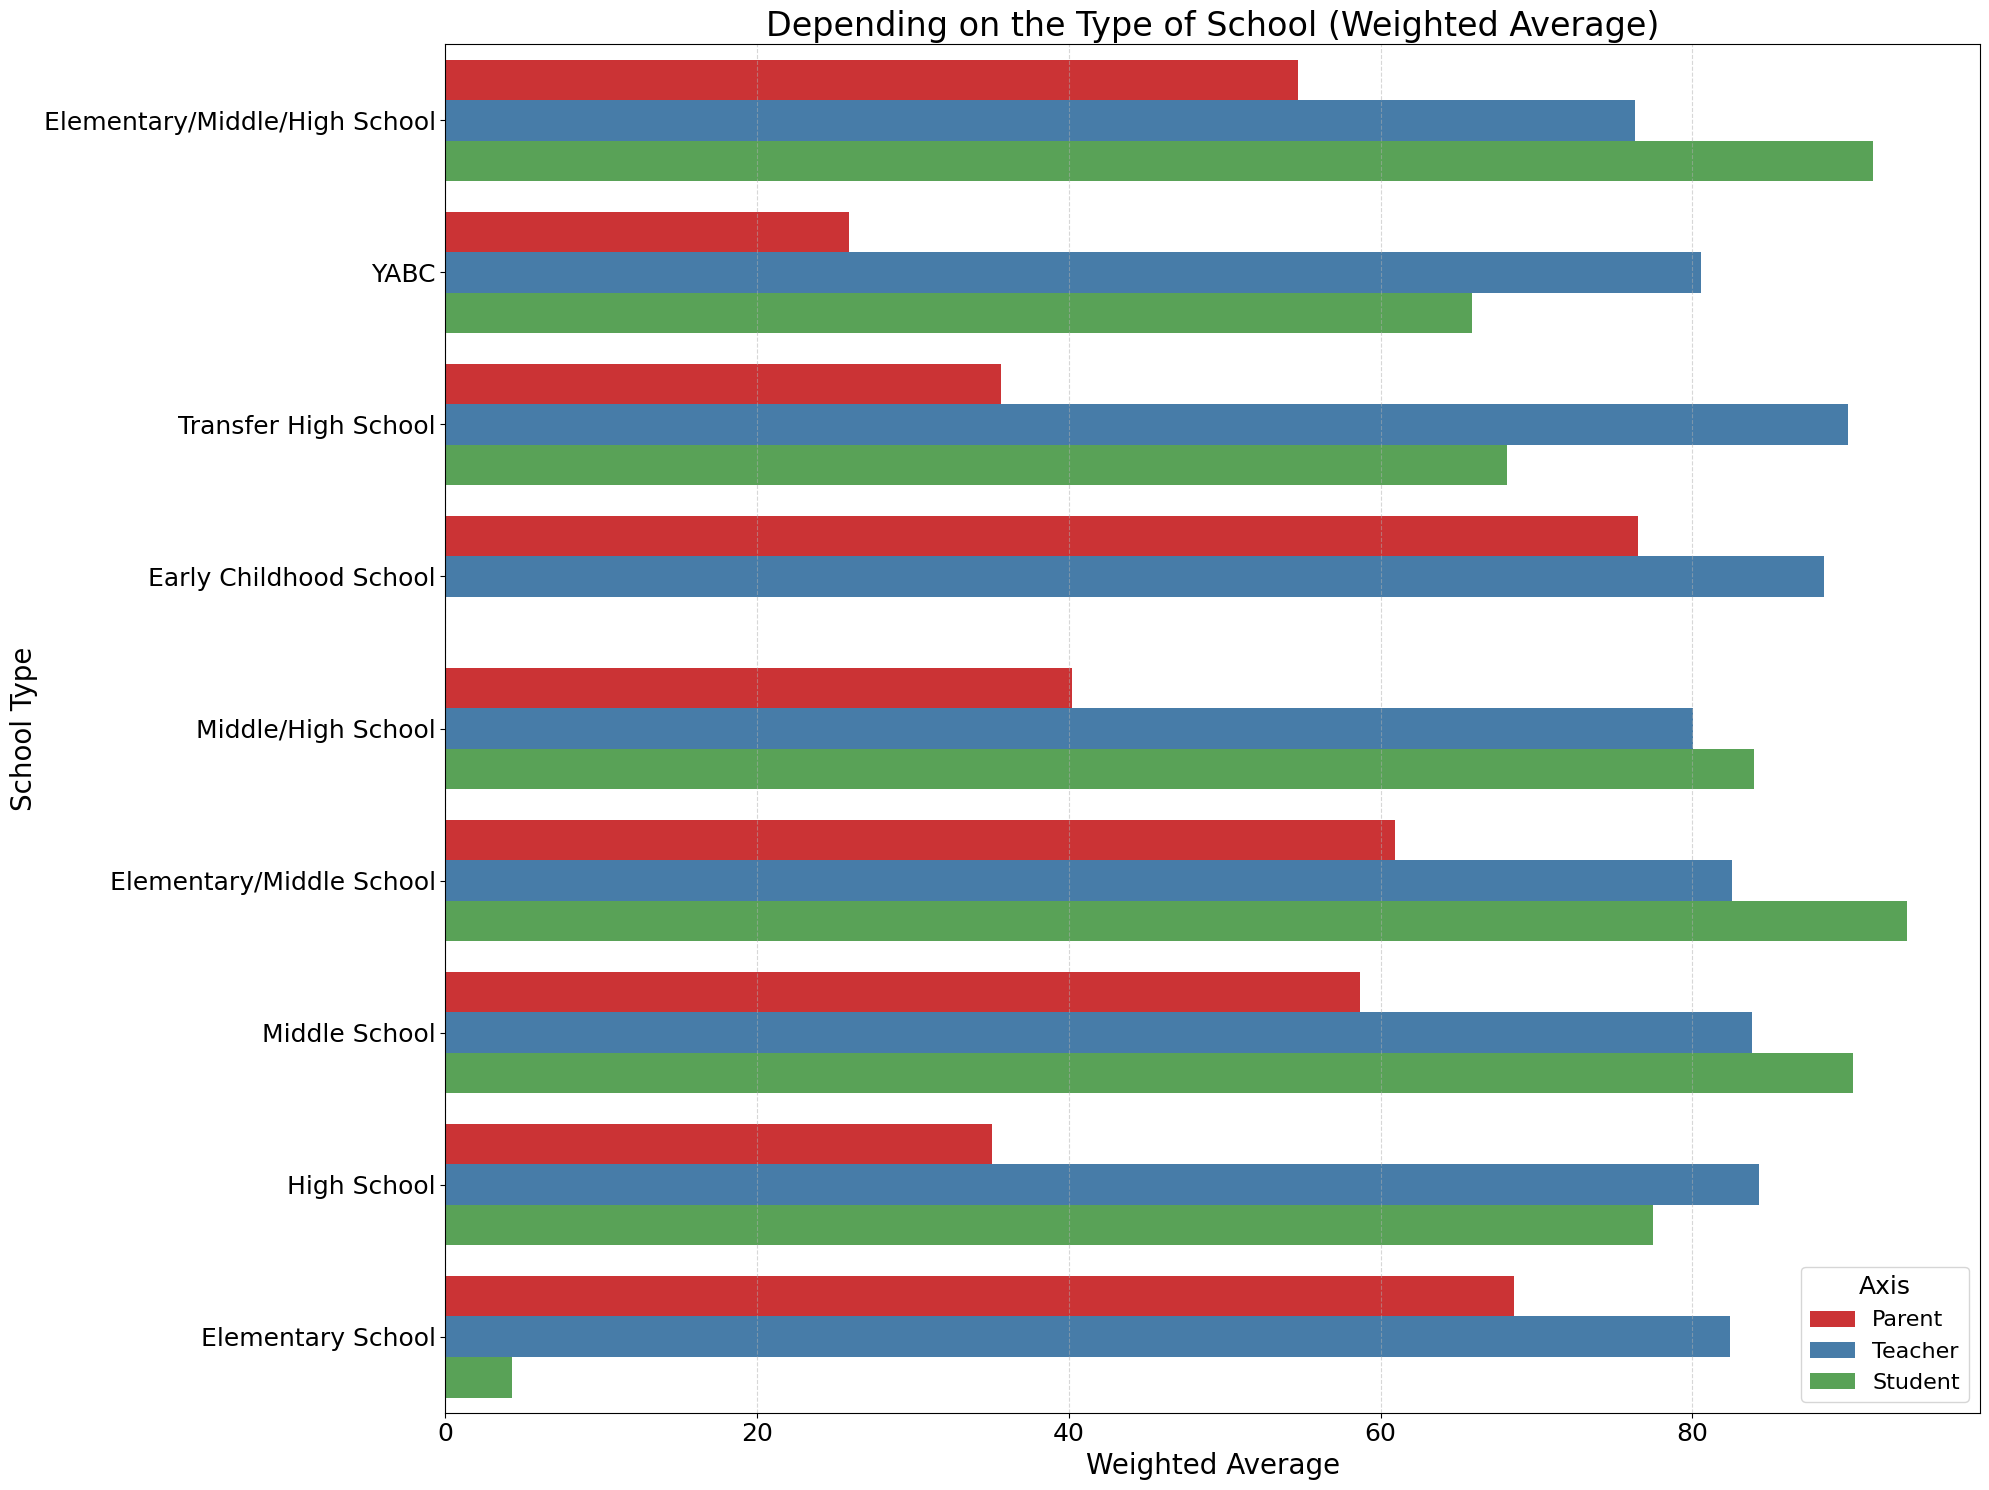

In [109]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define the columns that contain score values
score_cols = [
    'Parent Response Rate',
    'Teacher Response Rate',
    'Student Response Rate'
]

# Count the number of entries for each school type
school_counts = df['School Type'].value_counts()

# Assign weights to each row based on inverse frequency of the school type
df['weight'] = df['School Type'].map(1 / school_counts)

# Calculate weighted average scores per school type
weighted_means = df.groupby('School Type').apply(
    lambda g: pd.Series({
        col: (pd.to_numeric(g[col], errors='coerce') * pd.to_numeric(g['weight'], errors='coerce')).sum() /
             pd.to_numeric(g['weight'], errors='coerce').sum()
        for col in score_cols
    })
).reset_index()

# Sort the school types by number of entries (ascending)
sorted_types = school_counts.sort_values(ascending=True).index.to_list()

# Reorder rows in weighted_means to match the sorted order of school types
weighted_means = weighted_means.set_index('School Type').loc[sorted_types].reset_index()

# Rename score columns to shorter, readable labels
score_cols_readable = {
    'Parent Response Rate': 'Parent',
    'Teacher Response Rate': 'Teacher',
    'Student Response Rate': 'Student'
}

# Transform the data into long format for seaborn plotting
melted = weighted_means.melt(
    id_vars='School Type',
    value_vars=score_cols,
    var_name='Score Type',
    value_name='Weighted Score'
)

# Apply readable labels to score types
melted['Score Type'] = melted['Score Type'].map(score_cols_readable)

# Set figure size for better readability
plt.figure(figsize=(20, 15))

# Create horizontal bar plot of weighted average scores by school type
sns.barplot(
    data=melted,
    x='Weighted Score',
    y='School Type',
    hue='Score Type',
    palette='Set1'
)

# Add plot title and axis labels
plt.title('Depending on the Type of School (Weighted Average)', fontsize=24)
plt.xlabel('Weighted Average', fontsize=20)
plt.ylabel('School Type', fontsize=20)

# Customize legend and tick fonts
plt.legend(title='Axis', title_fontsize=18, fontsize=16)
plt.xticks(fontsize=18)
plt.yticks(fontsize=18)

# Improve layout and add gridlines for clarity
plt.tight_layout()
plt.grid(axis='x', linestyle='--', alpha=0.5)

# Show the plot
plt.show()


In [104]:

# Step 3: Pivot the DataFrame
df_Rate = melted.pivot(index="School Type", columns="Score Type", values="Weighted Score")

# Step 4: Rename columns to your desired names
df_Rate.columns = [
    "Parent",
    "Student",
    "Teacher"
]

# Optional: Reorder columns if needed
df_Rate = df_Rate[[
    "Parent",
    "Student",
    "Teacher"
]]

# Step 5: Display the final DataFrame
df_Rate

,Parent,Student,Teacher
School Type,,,
Early Childhood School,76.481481,0.000000,88.444444
Elementary School,68.526742,4.294976,82.418152
Elementary/Middle School,60.937500,93.762500,82.518750
Elementary/Middle/High School,54.714286,91.571429,76.285714
High School,35.093750,77.494318,84.252841
Middle School,58.681507,90.287671,83.832192
Middle/High School,40.218391,83.965517,80.045977
Transfer High School,35.653061,68.102041,89.959184
YABC,25.863636,65.863636,80.545455


In [110]:
# Merge the response rate DataFrame (df_Rate) with the score DataFrame (df_Score)
# using an inner join on the 'School Type' column to retain only matching school types
all_df = pd.merge(df_Rate, df_Score, on="School Type", how="inner")

# Display the merged DataFrame containing both response rates and performance scores
all_df


,Parent,Student,Teacher,Safety and Respect,Communication,Engagement,Academic Expectations
School Type,,,,,,,
Early Childhood School,76.481481,0.000000,88.444444,8.386420,8.027160,8.162963,8.637037
Elementary School,68.526742,4.294976,82.418152,8.051053,7.645867,7.872609,8.273906
Elementary/Middle School,60.937500,93.762500,82.518750,7.961250,7.245625,7.536250,7.661250
Elementary/Middle/High School,54.714286,91.571429,76.285714,7.514286,6.857143,7.128571,7.471429
High School,35.093750,77.494318,84.252841,7.530966,6.848864,7.157102,7.394886
Middle School,58.681507,90.287671,83.832192,7.804795,7.065753,7.416781,7.453082
Middle/High School,40.218391,83.965517,80.045977,7.514943,6.847126,7.124138,7.398851
Transfer High School,35.653061,68.102041,89.959184,8.044898,7.238776,7.775510,8.091837
YABC,25.863636,65.863636,80.545455,8.368182,7.700000,8.159091,8.377273


In [112]:
all_df.describe()

,Parent,Student,Teacher,Safety and Respect,Communication,Engagement,Academic Expectations
count,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000,9.000000
mean,50.685595,63.926899,83.144745,7.908532,7.275146,7.592557,7.862172
std,17.189297,36.398303,4.191489,0.343694,0.428536,0.420805,0.484954
min,25.863636,0.000000,76.285714,7.514286,6.847126,7.124138,7.394886
25%,35.653061,65.863636,80.545455,7.530966,6.857143,7.157102,7.453082
50%,54.714286,77.494318,82.518750,7.961250,7.238776,7.536250,7.661250
75%,60.937500,90.287671,84.252841,8.051053,7.645867,7.872609,8.273906
max,76.481481,93.762500,89.959184,8.386420,8.027160,8.162963,8.637037


In [113]:
df.describe()

,Parent Response Rate,Teacher Response Rate,Student Response Rate,Total Safety and Respect Score,Total Communication Score,Total Engagement Score,Total Academic Expectations Score,weight
count,1667.0,1667.0,1667.0,1667.000000,1667.000000,1667.000000,1667.000000,1667.000000
mean,56.335933,83.403119,50.405519,7.850330,7.299820,7.582244,7.879544,0.005399
std,25.008905,17.426696,43.317526,0.745997,0.697943,0.662616,0.624073,0.010905
min,1.0,0.0,0.0,4.700000,4.700000,4.800000,5.300000,0.001621
25%,37.0,75.0,0.0,7.300000,6.800000,7.100000,7.500000,0.001621
50%,57.0,88.0,71.0,7.900000,7.300000,7.600000,7.900000,0.002841
75%,76.0,97.0,92.0,8.400000,7.800000,8.000000,8.300000,0.003425
max,100.0,100.0,100.0,9.600000,9.200000,9.300000,9.500000,0.142857


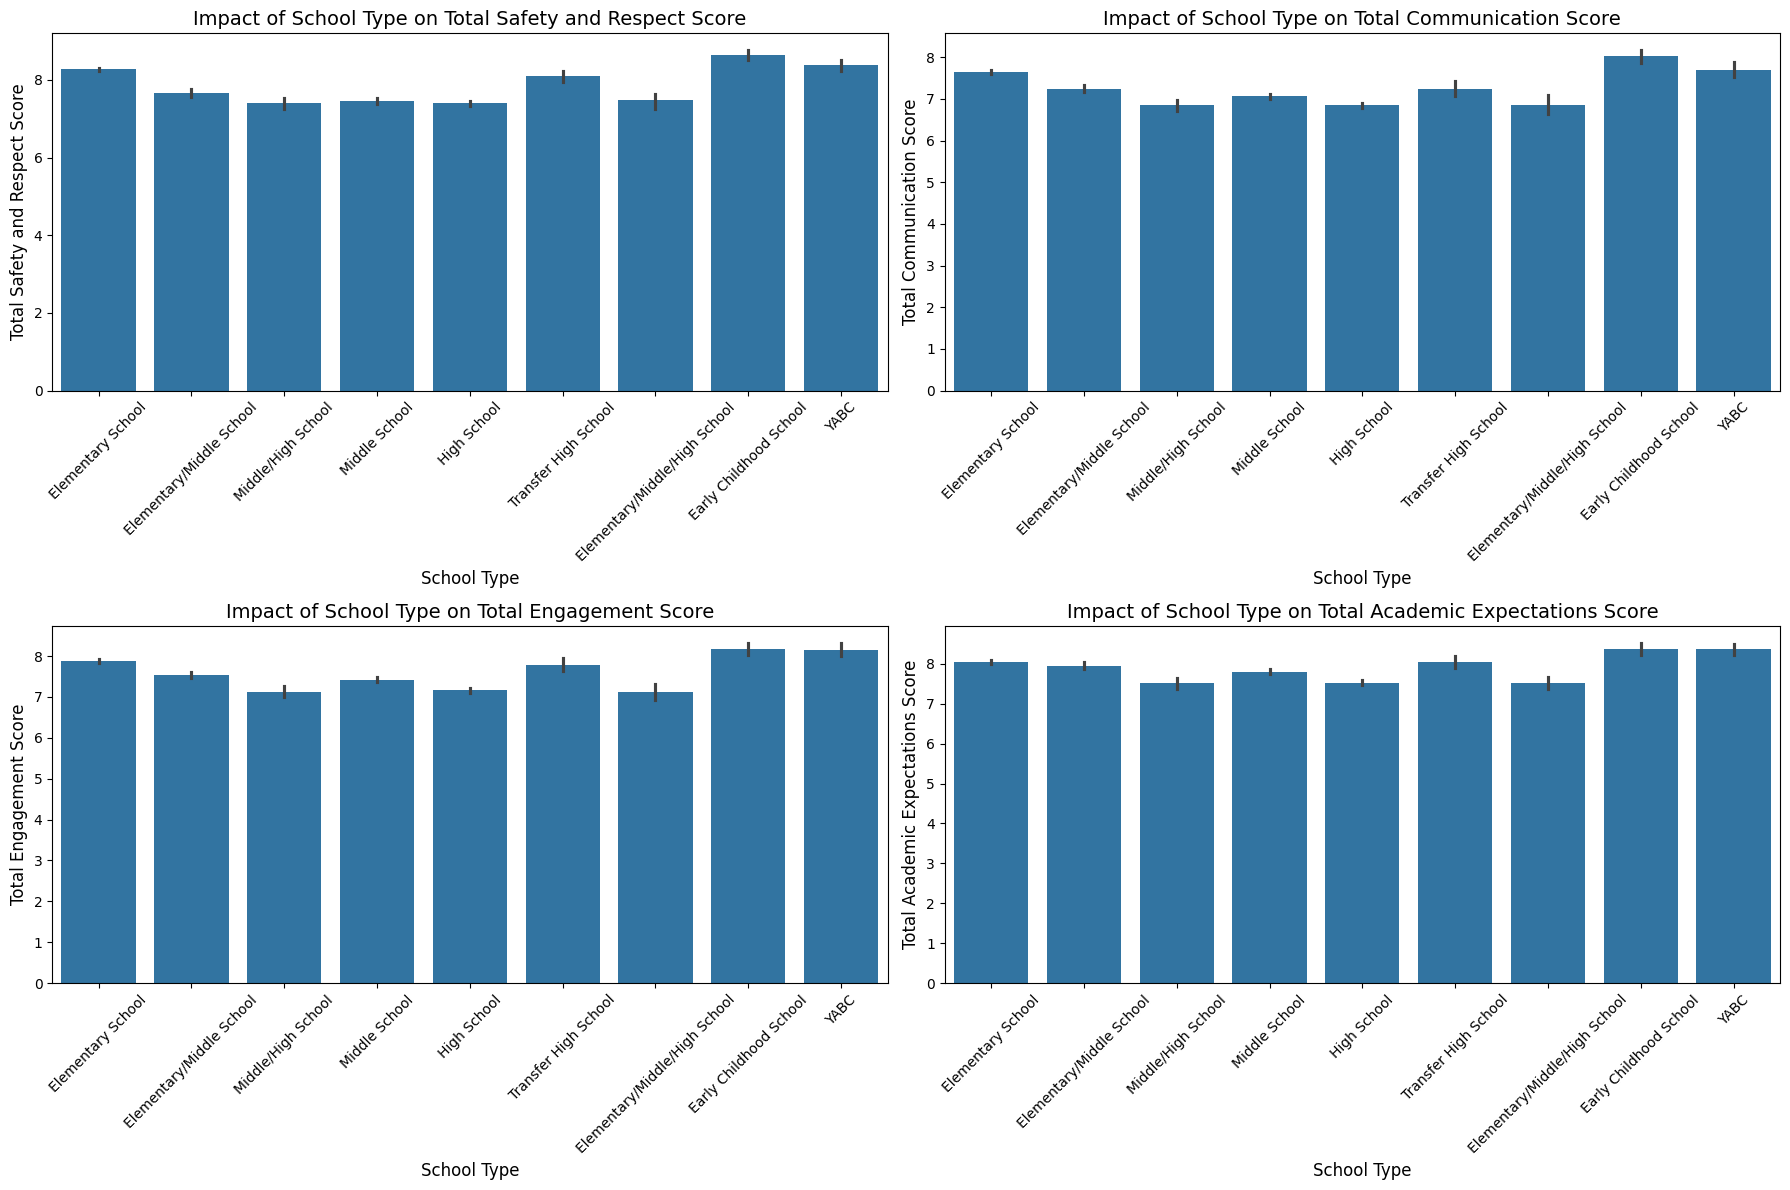

In [88]:
# List of score columns to analyze the impact of School Type
score_columns = [
    'Total Safety and Respect Score',
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score'
]

# Create a 2x2 grid of subplots to visualize all scores side-by-side
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Loop through each score column and corresponding subplot axis
for ax, col in zip(axes.flat, score_columns):
    # Draw a boxplot showing the distribution of scores by School Type
    sns.barplot(x='School Type', y=col, data=df, ax=ax)

    # Set title and axis labels for clarity
    ax.set_title(f'Impact of School Type on {col}', fontsize=14)
    ax.set_xlabel('School Type', fontsize=12)
    ax.set_ylabel(col, fontsize=12)

    # Rotate x-axis labels for better readability
    ax.tick_params(axis='x', rotation=45)

# Adjust layout to prevent overlap of plot elements
plt.tight_layout()

# Display all boxplots in a single figure window
plt.show()

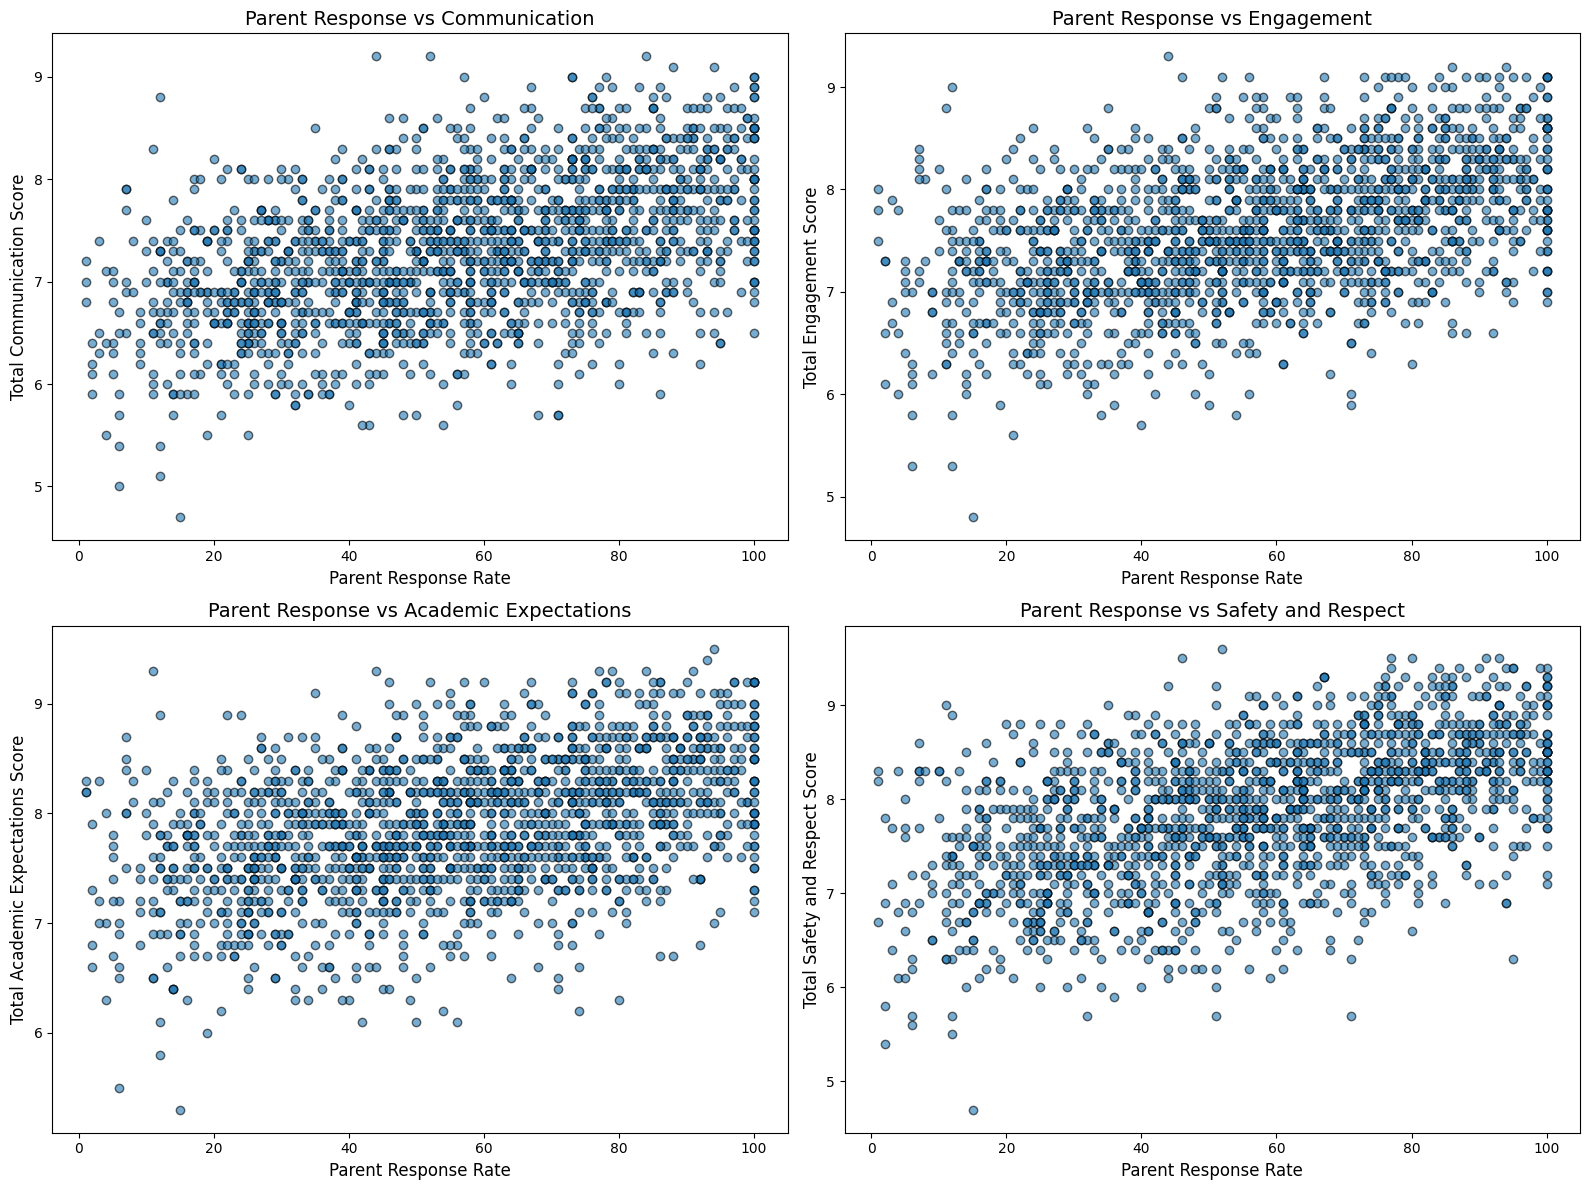

In [89]:
# Create a 2x2 grid of subplots for comparing multiple variables in one window
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define the target metrics to compare with Parent Response Rate
metrics = [
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score',
    'Total Safety and Respect Score'
]

# Define corresponding titles for each subplot for clarity
titles = [
    'Parent Response vs Communication',
    'Parent Response vs Engagement',
    'Parent Response vs Academic Expectations',
    'Parent Response vs Safety and Respect'
]

# Loop over each axis, metric, and title to create individual scatter plots
for ax, metric, title in zip(axes.flat, metrics, titles):
    # Scatter plot showing the relationship between Parent Response Rate and the current metric
    ax.scatter(df['Parent Response Rate'], df[metric], alpha=0.6, edgecolors='k')

    # Set subplot title and axis labels for readability
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Parent Response Rate', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display all plots in a single window
plt.show()

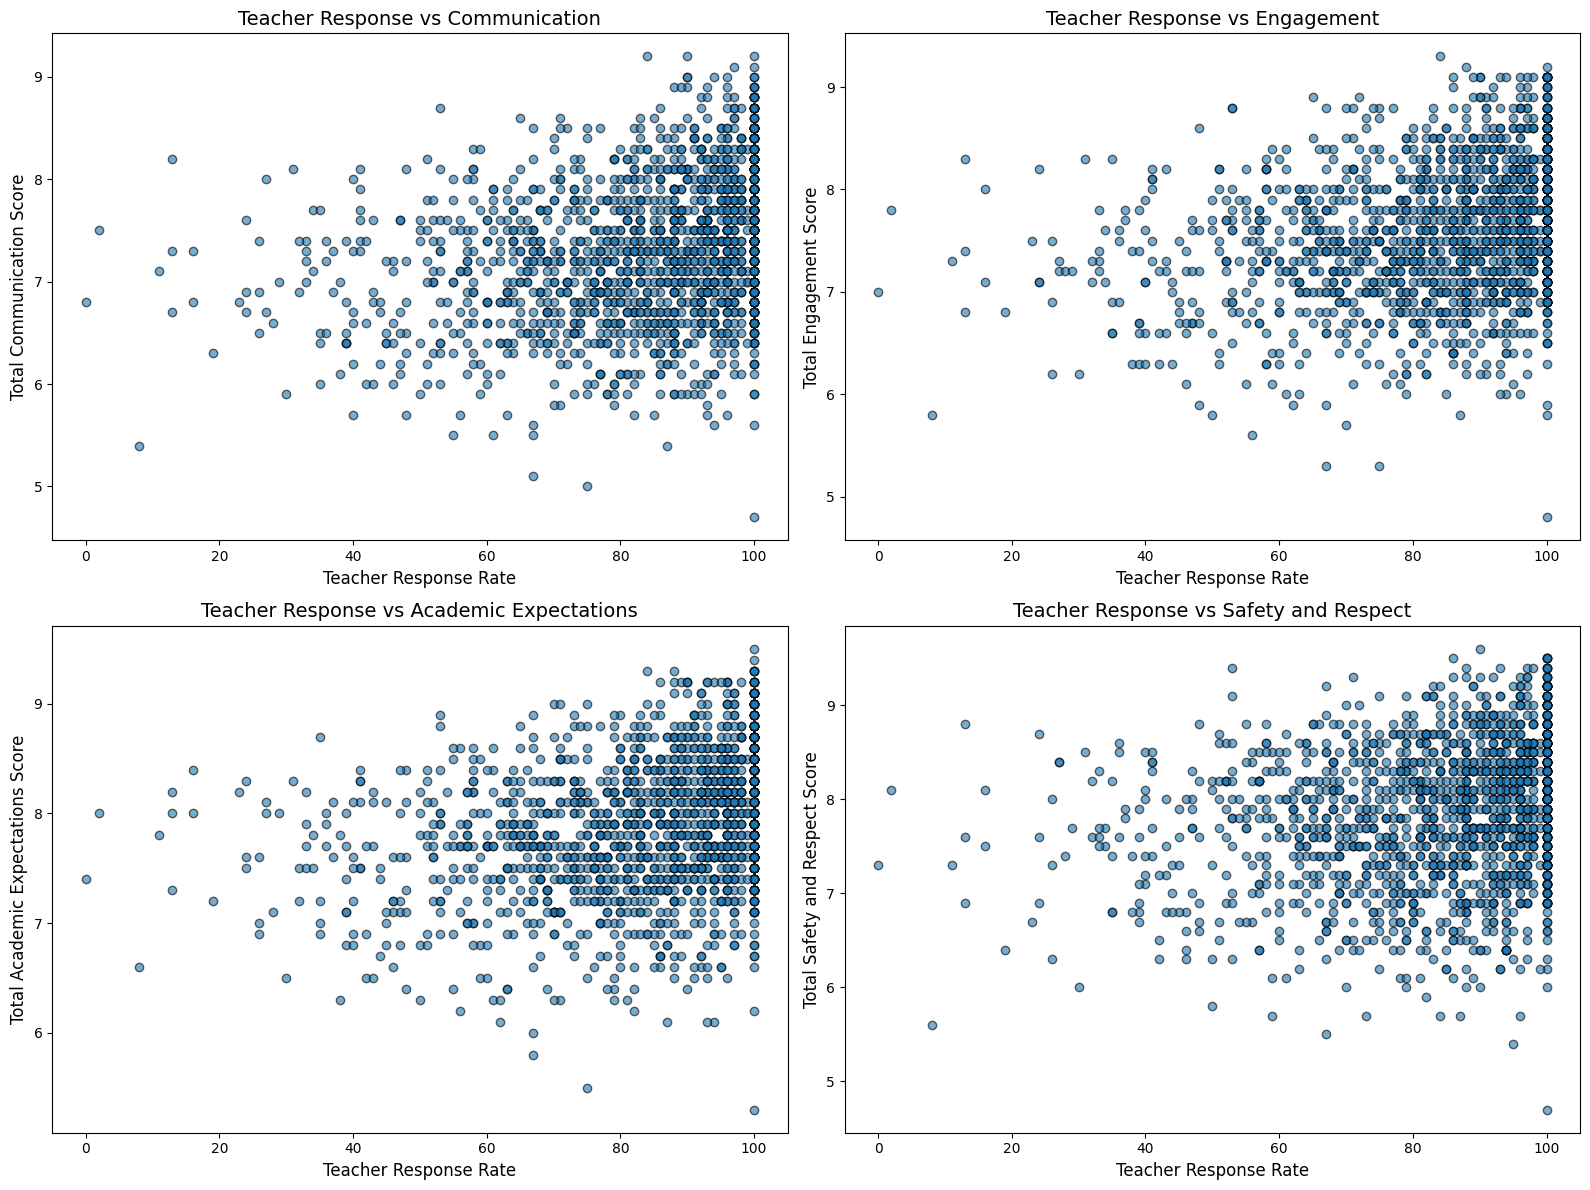

In [90]:
# Create a 2x2 grid of subplots for comparing multiple variables in one window
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define the target metrics to compare with Parent Response Rate
metrics = [
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score',
    'Total Safety and Respect Score'
]

# Define corresponding titles for each subplot for clarity
titles = [
    'Teacher Response vs Communication',
    'Teacher Response vs Engagement',
    'Teacher Response vs Academic Expectations',
    'Teacher Response vs Safety and Respect'
]

# Loop over each axis, metric, and title to create individual scatter plots
for ax, metric, title in zip(axes.flat, metrics, titles):
    # Scatter plot showing the relationship between Parent Response Rate and the current metric
    ax.scatter(df['Teacher Response Rate'], df[metric], alpha=0.6, edgecolors='k')

    # Set subplot title and axis labels for readability
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Teacher Response Rate', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display all plots in a single window
plt.show()

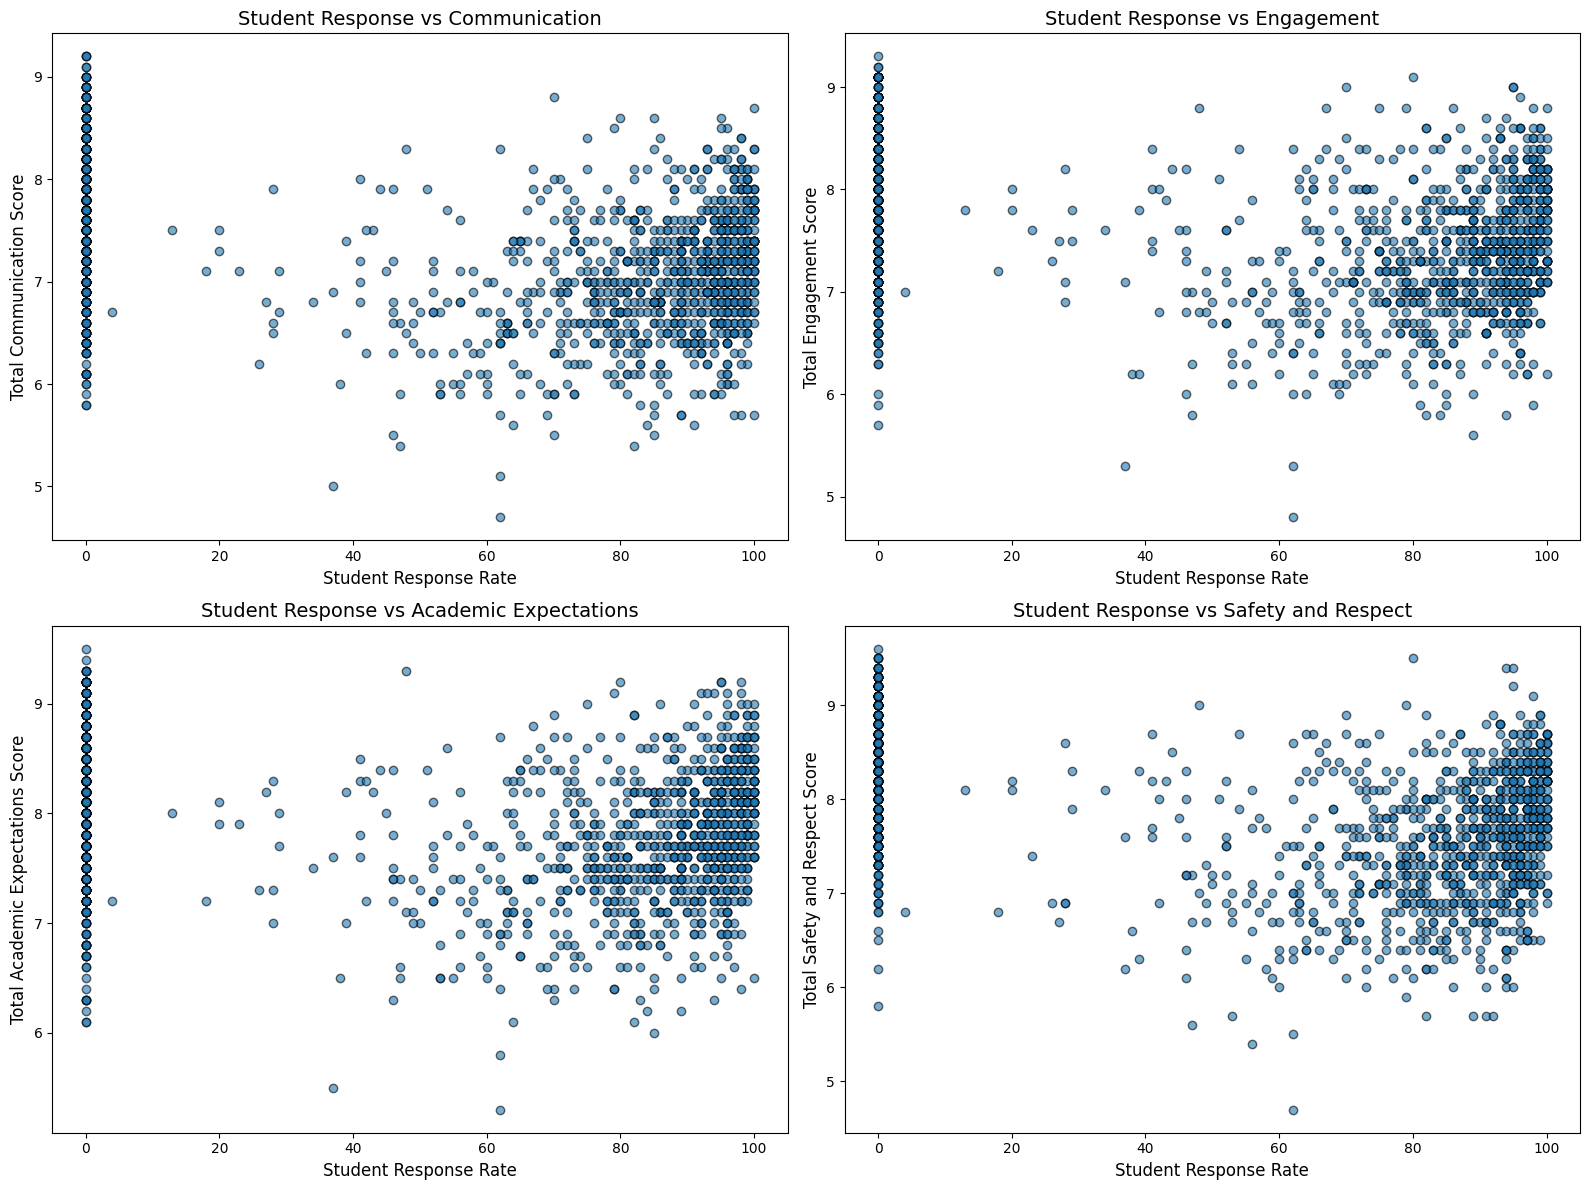

In [91]:
# Create a 2x2 grid of subplots for comparing multiple variables in one window
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Define the target metrics to compare with Parent Response Rate
metrics = [
    'Total Communication Score',
    'Total Engagement Score',
    'Total Academic Expectations Score',
    'Total Safety and Respect Score'
]

# Define corresponding titles for each subplot for clarity
titles = [
    'Student Response vs Communication',
    'Student Response vs Engagement',
    'Student Response vs Academic Expectations',
    'Student Response vs Safety and Respect'
]

# Loop over each axis, metric, and title to create individual scatter plots
for ax, metric, title in zip(axes.flat, metrics, titles):
    # Scatter plot showing the relationship between Parent Response Rate and the current metric
    ax.scatter(df['Student Response Rate'], df[metric], alpha=0.6, edgecolors='k')

    # Set subplot title and axis labels for readability
    ax.set_title(title, fontsize=14)
    ax.set_xlabel('Student Response Rate', fontsize=12)
    ax.set_ylabel(metric, fontsize=12)

# Adjust layout to prevent overlapping of elements
plt.tight_layout()

# Display all plots in a single window
plt.show()